In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_opto-mFC_2/goalNav/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_opto-mFC_2/goalNav/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)

## Exp. Design
Write some text about experimental design

## Performance Metrics

#### Learning
Start simple, lets look at trials across learning between conditions & in expert behaviour (when stim starts)

In [3]:
from GridMaze.analysis.behaviour import learning as bl

learning_df = bl.get_learning_curve_df()
expert_df = bl.get_expert_performance_df()

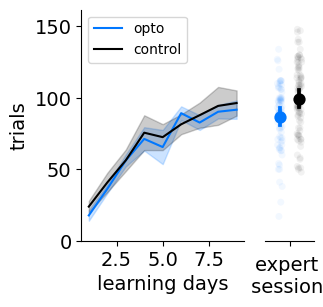

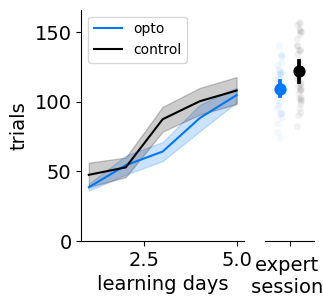

: 

In [ ]:
reload(bl)
for maze_order in [1, 2]:
    fig, axes = plt.subplots(1, 2, figsize=(3, 3), width_ratios=[1, 0.3], sharey=True)
    bl.plot_performance_summary(learning_df, expert_df, maze_order=maze_order, print_stats=False, axes=axes)
    fig.savefig(f"../results/figures/learning_maze_order_{maze_order}.pdf")

#### Excess steps (during expert behaviour with mFC inhibition)

In [3]:
import numpy as np
from GridMaze.analysis.behaviour import excess_steps as es

excess_steps_df = es.get_excess_steps_df(verbose=False)

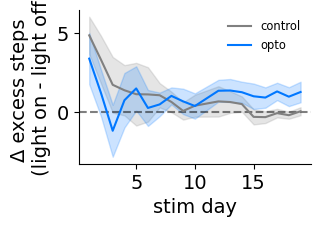

In [4]:
reload(es)
f, ax = plt.subplots(1, 1, figsize=(3, 2))
es.plot_stim_effects_over_days(excess_steps_df, outlier_thres=200, ax=ax)
f.savefig("../results/figures/delta_excess_steps_over_time.pdf")

        Source        SS  DF1  DF2        MS          F     p-unc       np2  \
0    condition  8.098098    1   13  8.098098  13.317759  0.002941  0.506037   
1   stim_trial  2.405399    1   13  2.405399  18.052196  0.000949  0.581350   
2  Interaction  1.886189    1   13  1.886189  14.155595  0.002371  0.521277   

   eps  
0  NaN  
1  1.0  
2  NaN  


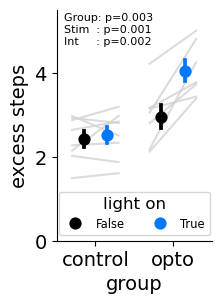

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(2, 3))
es.plot_random_effects_summary(
    excess_steps_df,
    stim_day_range=(8, np.inf),
    print_stats=True,
    ax=ax,
)
fig.savefig("../results/figures/random_effects_excess_steps.pdf")

        Source        SS  DF1  DF2        MS          F     p-unc       np2  \
0    condition  7.799899    1   13  7.799899  11.902724  0.004308  0.477969   
1   stim_trial  2.723170    1   13  2.723170  19.344361  0.000720  0.598075   
2  Interaction  1.777808    1   13  1.777808  12.628870  0.003531  0.492760   

   eps  
0  NaN  
1  1.0  
2  NaN  


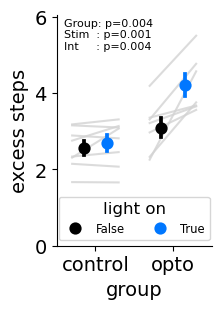

In [14]:
# focusing even more on late data
es.plot_random_effects_summary(
    excess_steps_df,
    stim_day_range=(4, np.inf),
    outlier_thres=250,
    print_stats=True,
)

In [4]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.behaviour import trajectory_plotting as tp

In [6]:
session = gs.get_maze_sessions(subject_IDs=["mFC-opto_23"], maze_names=["maze_2"], days_on_maze=[8])[0]

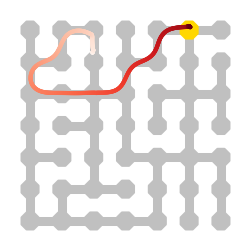

In [7]:
tp.plot_fancy_trial_trajectory(session, trial=27)

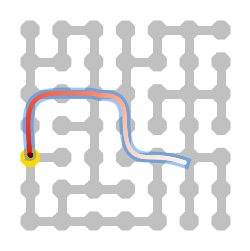

In [ ]:
tp.plot_fancy_trial_trajectory(session, trial=28)

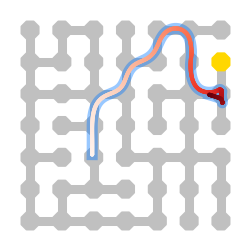

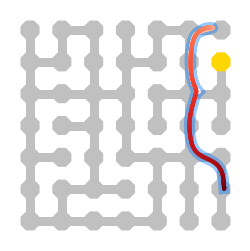

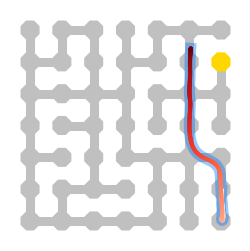

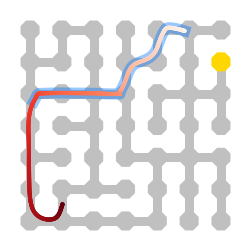

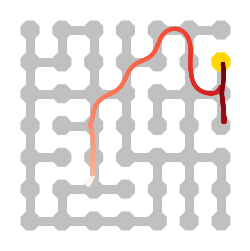

In [ ]:
for tr in [[0, 8.5], [8.5, 16], [16, 22], [22.5, 31], [31.5, 50]]:
    tp.plot_fancy_trial_trajectory(session, trial=29, t_range=tr)

In [16]:
session2 = gs.get_maze_sessions(subject_IDs=["mFC-opto_23"], maze_names=["maze_2"], days_on_maze=[9])[0]

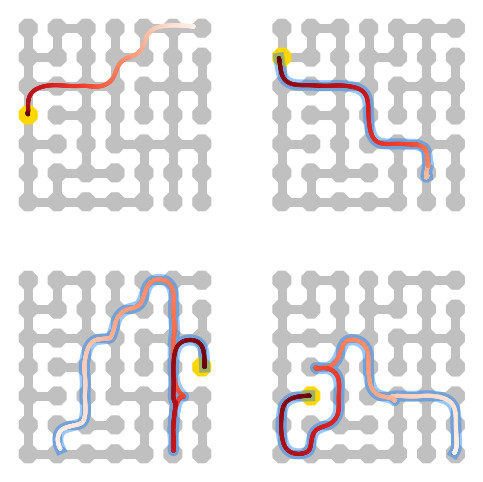

In [29]:
f, axes = plt.subplots(2, 2, figsize=(6, 6))
for ax, (t, t_range) in zip(axes.flatten(), zip([40, 4, 43, 64], [None, None, None, [5.5, 30]])):
    tp.plot_fancy_trial_trajectory(session2, trial=t, t_range=t_range, ax=ax)